<a href="https://colab.research.google.com/github/giri-infinity/pratice-code/blob/main/cnn_cifar_10%EC%9D%98_%EC%82%AC%EB%B3%B8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


(50000, 32, 32, 3) (10000, 32, 32, 3)
(50000, 1) (10000, 1)
Epoch 1/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 150s 377ms/step - accuracy: 0.3900 - loss: 1.6467 - val_accuracy: 0.5244 - val_loss: 1.3131
Epoch 2/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 150s 382ms/step - accuracy: 0.5492 - loss: 1.2572 - val_accuracy: 0.5829 - val_loss: 1.1891
Epoch 3/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 149s 381ms/step - accuracy: 0.6075 - loss: 1.1050 - val_accuracy: 0.6570 - val_loss: 0.9628
Epoch 4/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 148s 380ms/step - accuracy: 0.6506 - loss: 0.9869 - val_accuracy: 0.6874 - val_loss: 0.8827
Epoch 5/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 149s 381ms/step - accuracy: 0.6802 - loss: 0.9069 - val_accuracy: 0.7113 - val_loss: 0.8236
313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step - accuracy: 0.7113 - loss: 0.8236
정확률은 71.13000154495239


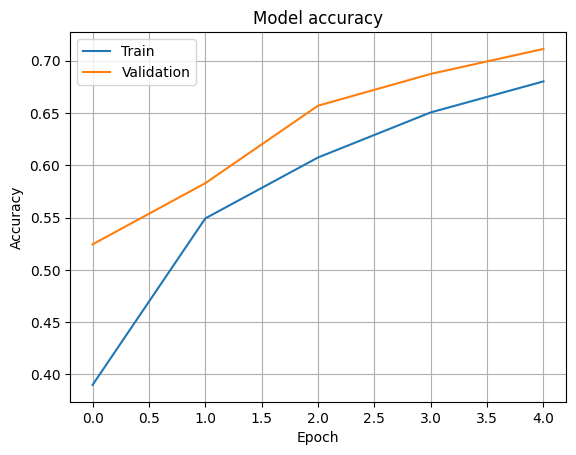

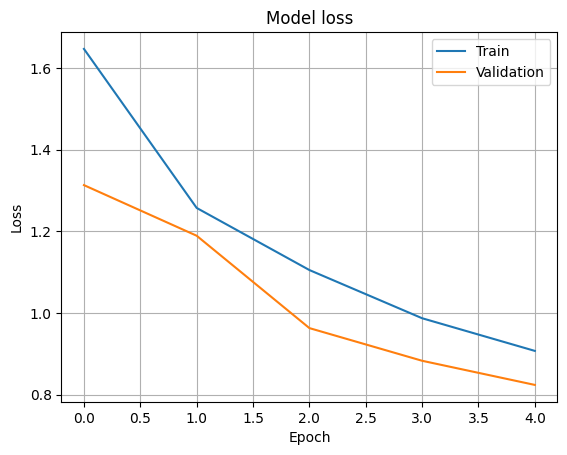

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D,MaxPooling2D,Flatten,Dense,Dropout
from tensorflow.keras.optimizers import Adam #Gradient Descent Optimizer

# CIFAR-10 데이터셋을 읽고 신경망에 입력할 형태로 변환
(x_train,y_train),(x_test,y_test)=cifar10.load_data()
print(x_train.shape,x_test.shape)
print(y_train.shape,y_test.shape)
x_train=x_train.astype(np.float32)/255.0
x_test=x_test.astype(np.float32)/255.0
y_train=tf.keras.utils.to_categorical(y_train,10)
y_test=tf.keras.utils.to_categorical(y_test,10)

# 신경망 모델 설계
cnn=Sequential()
cnn.add(Conv2D(32,(3,3),activation='relu',input_shape=(32,32,3)))
cnn.add(Conv2D(32,(3,3),activation='relu'))
cnn.add(MaxPooling2D(pool_size=(2,2)))
cnn.add(Dropout(0.25))
cnn.add(Conv2D(64,(3,3),activation='relu'))
cnn.add(Conv2D(64,(3,3),activation='relu'))
cnn.add(MaxPooling2D(pool_size=(2,2)))
cnn.add(Dropout(0.25))
cnn.add(Flatten())
cnn.add(Dense(512,activation='relu'))
cnn.add(Dropout(0.5))
cnn.add(Dense(10,activation='softmax'))

# 신경망 모델 학습
cnn.compile(loss='categorical_crossentropy',optimizer=Adam(),metrics=['accuracy'])
hist=cnn.fit(x_train,y_train,batch_size=128,epochs=5,validation_data=(x_test,y_test),verbose=1)

# 신경망 모델 정확률 평가
res=cnn.evaluate(x_test,y_test,verbose=1)
print("정확률은",res[1]*100)

import matplotlib.pyplot as plt

# 정확률 그래프
plt.plot(hist.history['accuracy'])
plt.plot(hist.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train','Validation'], loc='best')
plt.grid()
plt.show()

# 손실 함수 그래프
plt.plot(hist.history['loss'])
plt.plot(hist.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train','Validation'],loc='best')
plt.grid()
plt.show()
cnn.save("my_cnn.h5")